# Late Fusion Model with EEG (No Temporal Behavior Features)

This notebook implements late fusion combining:
- **Physiological data** (pupil metrics)
- **Behavioral data** (WITHOUT reaction_time, decision_time, ambiguity)
- **Gaze data** (gaze position, movements, fixations)
- **EEG data** (band power features)

**Note**: 
- This version excludes reaction_time, decision_time, and ambiguity from behavioral features.
- EEG data is available for **85 subjects** (82 overlap with extracted features)
- EEG data is from the **display/decision phase (PRE-decision period only)**
- This notebook uses `TIMEFRAME = 'PRE'`

In [1]:
# ============================================================================
# CONFIGURATION
# ============================================================================
# EEG data is only available for PRE-decision period (display phase)
TIMEFRAME = 'PRE'  # Fixed to PRE - EEG is from display/decision phase
# ============================================================================

import sys
sys.path.append('../..')  # Add project root to path

import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer
from scipy import stats, signal
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Import from src package
from src.utils.io import load_features, save_results
from src.utils.config import get_model_params, load_config
from src.utils.validation import validate_features, validate_modality_features
from src.models.fusion import weighted_late_fusion
from src.visualization.plots import (
    plot_method_comparison,
    plot_modality_weights,
    set_style
)

np.random.seed(42)
set_style('whitegrid')

print(f"\n{'='*70}")
print(f"LATE FUSION WITH EEG (NO TEMPORAL BEHAVIOR): {TIMEFRAME}-DECISION PERIOD")
print(f"Excluded behavior features: reaction_time, decision_time, ambiguity")
print(f"Note: EEG data is from display/decision phase (PRE only)")
print(f"{'='*70}\n")


LATE FUSION WITH EEG (NO TEMPORAL BEHAVIOR): PRE-DECISION PERIOD
Excluded behavior features: reaction_time, decision_time, ambiguity
Note: EEG data is from display/decision phase (PRE only)



## 1. Load Pre-Extracted Features

In [2]:
# Load configuration
config = load_config('model_params')
time_window = config['time_windows'][f'{TIMEFRAME.lower()}_decision']

print(f"Time window: {time_window['start']}s to {time_window['end']}s")
print(f"Description: {time_window['description']}\n")

# Load pre-extracted features using src utilities
features_path = f'../../data/results/features_{TIMEFRAME}/extracted_features_{TIMEFRAME}.pkl'
feature_data = load_features(features_path, timeframe=TIMEFRAME)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
behavior_cols_original = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

# EXCLUDE reaction_time, decision_time, and ambiguity from behavior features
excluded_features = ['reaction_time', 'decision_time', 'ambiguity']
behavior_cols = [col for col in behavior_cols_original if col not in excluded_features]

print(f"Original behavior features: {behavior_cols_original}")
print(f"Excluded features: {excluded_features}")
print(f"Remaining behavior features: {behavior_cols}")

# Validate loaded features
validate_features(merged_df, timeframe=TIMEFRAME)

Time window: -2.0s to 0.0s
Description: Anticipatory period before submit button

Original behavior features: ['reaction_time', 'decision_time', 'ev_difference', 'invest_variance', 'ambiguity', 'condition_social', 'risk_premium']
Excluded features: ['reaction_time', 'decision_time', 'ambiguity']
Remaining behavior features: ['ev_difference', 'invest_variance', 'condition_social', 'risk_premium']
✓ Validation passed (PRE): 12511 trials, 97 subjects
  Trials per subject: min=9, max=246, mean=129.0
  Outcome balance: 4273 keep / 8238 invest


## 2. Load and Extract EEG Features

In [3]:
# EEG feature extraction parameters
freq_bands = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 13),
    'Beta': (13, 30),
    'Gamma': (30, 50)
}

channel_names = [
    'Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
    'T3', 'C3', 'Cz', 'C4', 'T4',
    'T5', 'P3', 'Pz', 'P4', 'T6',
    'O1', 'Oz', 'O2'
]

channel_regions = {
    'Frontal': ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8'],
    'Central': ['T3', 'C3', 'Cz', 'C4', 'T4'],
    'Parietal': ['T5', 'P3', 'Pz', 'P4', 'T6'],
    'Occipital': ['O1', 'Oz', 'O2']
}

def compute_band_power(eeg_data, fs=256, bands=None):
    """Compute band power for each channel and frequency band."""
    if bands is None:
        bands = freq_bands
    
    freqs, psd = signal.welch(eeg_data, fs=fs, nperseg=min(256, eeg_data.shape[1]))
    
    band_powers = {}
    for band_name, (f_low, f_high) in bands.items():
        freq_mask = (freqs >= f_low) & (freqs <= f_high)
        band_power = np.trapz(psd[:, freq_mask], freqs[freq_mask], axis=1)
        band_powers[band_name] = band_power
    
    return band_powers

def extract_eeg_features(eeg_df, fs=256):
    """Extract band power features for all trials.
    
    The EEG file has display_eeg with shape (time, channels).
    We transpose to (channels, time) for processing.
    """
    features_list = []
    
    for idx, row in eeg_df.iterrows():
        # display_eeg has shape (320, 20) = (time, channels)
        # Transpose to (20, 320) = (channels, time) for band power computation
        display_eeg = np.array(row['display_eeg']).T
        bp = compute_band_power(display_eeg, fs)
        
        trial_features = {
            'subject_id': row['subject_date_id'],
            'trial_id': f"{row['trial_id']}_{row['subject_date_id']}"
        }
        
        for band_name in freq_bands.keys():
            band_power = bp[band_name]
            for region, channels in channel_regions.items():
                ch_indices = [channel_names.index(ch) for ch in channels]
                avg_power = np.mean(band_power[ch_indices])
                trial_features[f'eeg_{band_name}_{region}'] = avg_power
        
        features_list.append(trial_features)
    
    return pd.DataFrame(features_list)

# Load preprocessed EEG data (85 subjects)
eeg_file = '../../data/eeg/Copy of preprocessed_eeg.pkl'
print(f"Loading EEG data from: {eeg_file}")
with open(eeg_file, 'rb') as f:
    eeg_raw_df = pickle.load(f)

print(f"Loaded {len(eeg_raw_df)} EEG trials from {eeg_raw_df['subject_date_id'].nunique()} subjects")

# Extract EEG features
print("\nExtracting EEG features from display_eeg...")
eeg_features_df = extract_eeg_features(eeg_raw_df, fs=256)
eeg_cols = [c for c in eeg_features_df.columns if c.startswith('eeg_')]

print(f"Extracted {len(eeg_cols)} EEG features")
print(f"EEG subjects: {len(eeg_features_df['subject_id'].unique())}")

Loading EEG data from: ../../data/eeg/Copy of preprocessed_eeg.pkl
Loaded 10855 EEG trials from 85 subjects

Extracting EEG features from display_eeg...
Extracted 20 EEG features
EEG subjects: 85


## 3. Merge Features and Filter to EEG Subjects

In [4]:
# Get EEG subjects
eeg_subjects = eeg_features_df['subject_id'].unique()
print(f"EEG subjects: {len(eeg_subjects)}")

# Filter merged_df to only EEG subjects
merged_df_eeg = merged_df[merged_df['subject_id'].isin(eeg_subjects)].copy()
print(f"\nFiltered to EEG subjects: {len(merged_df_eeg)} trials")

# Merge with EEG features on trial_id
merged_df_eeg = merged_df_eeg.merge(
    eeg_features_df[['trial_id'] + eeg_cols],
    on='trial_id',
    how='inner'
)

print(f"After merging with EEG: {len(merged_df_eeg)} trials")
print(f"Subjects: {merged_df_eeg['subject_id'].nunique()}")

# Check outcome balance
outcome_counts = merged_df_eeg['outcome'].value_counts()
print(f"\nOutcome balance: {outcome_counts.get(0, 0)} keep / {outcome_counts.get(1, 0)} invest")

print(f"\nFeature counts:")
print(f"  Physiology ({TIMEFRAME}): {len(physio_cols)} features")
print(f"  Behavior (filtered): {len(behavior_cols)} features")
print(f"  Gaze: {len(gaze_cols)} features")
print(f"  EEG: {len(eeg_cols)} features")

EEG subjects: 85

Filtered to EEG subjects: 10732 trials
After merging with EEG: 10431 trials
Subjects: 82

Outcome balance: 3550 keep / 6881 invest

Feature counts:
  Physiology (PRE): 13 features
  Behavior (filtered): 4 features
  Gaze: 20 features
  EEG: 20 features


## 4. Prepare Feature Sets

In [5]:
# Prepare feature arrays for model training
imputer = SimpleImputer(strategy='mean')
X_physio = imputer.fit_transform(merged_df_eeg[physio_cols])
X_behavior = imputer.fit_transform(merged_df_eeg[behavior_cols])
X_gaze = imputer.fit_transform(merged_df_eeg[gaze_cols]) if len(gaze_cols) > 0 else np.zeros((len(merged_df_eeg), 1))
X_eeg = imputer.fit_transform(merged_df_eeg[eeg_cols])

y = merged_df_eeg['outcome'].values
subjects = merged_df_eeg['subject_id'].values

print(f"Shapes:")
print(f"  X_physio: {X_physio.shape}")
print(f"  X_behavior: {X_behavior.shape}")
print(f"  X_gaze: {X_gaze.shape}")
print(f"  X_eeg: {X_eeg.shape}")

Shapes:
  X_physio: (10431, 13)
  X_behavior: (10431, 4)
  X_gaze: (10431, 20)
  X_eeg: (10431, 20)


In [6]:
def train_evaluate_modality(X, y, subjects, modality_name):
    """
    Train and evaluate a single modality using LOSO cross-validation.
    """
    logo = LeaveOneGroupOut()
    model_params = get_model_params('random_forest')
    
    all_preds = []
    all_y_true = []
    subject_accs = []
    subject_f1s = []
    
    print(f"\n{'='*50}")
    print(f"{modality_name} Model")
    print(f"{'='*50}")
    
    for train_idx, test_idx in logo.split(X, y, subjects):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model = RandomForestClassifier(**model_params)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        all_preds.extend(y_pred)
        all_y_true.extend(y_test)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        subject_accs.append(acc)
        subject_f1s.append(f1)
    
    overall_acc = np.mean(subject_accs)
    overall_f1 = np.mean(subject_f1s)
    
    print(f"Accuracy: {overall_acc:.3f} +/- {stats.sem(subject_accs):.3f}")
    print(f"F1-Score: {overall_f1:.3f} +/- {stats.sem(subject_f1s):.3f}")
    print(f"N subjects: {len(subject_accs)}")
    
    return model, overall_acc, overall_f1, np.array(all_preds), np.array(all_y_true)

## 5. Train Individual Modality Models

In [7]:
model_physio, acc_physio, f1_physio, pred_physio, y_true = train_evaluate_modality(
    X_physio, y, subjects, "Physiology"
)
model_behavior, acc_behavior, f1_behavior, pred_behavior, _ = train_evaluate_modality(
    X_behavior, y, subjects, "Behavior (No Temporal)"
)
model_gaze, acc_gaze, f1_gaze, pred_gaze, _ = train_evaluate_modality(
    X_gaze, y, subjects, "Gaze"
)
model_eeg, acc_eeg, f1_eeg, pred_eeg, _ = train_evaluate_modality(
    X_eeg, y, subjects, "EEG"
)


Physiology Model
Accuracy: 0.518 +/- 0.015
F1-Score: 0.508 +/- 0.019
N subjects: 82

Behavior (No Temporal) Model
Accuracy: 0.522 +/- 0.015
F1-Score: 0.553 +/- 0.014
N subjects: 82

Gaze Model
Accuracy: 0.519 +/- 0.013
F1-Score: 0.524 +/- 0.015
N subjects: 82

EEG Model
Accuracy: 0.540 +/- 0.016
F1-Score: 0.517 +/- 0.018
N subjects: 82


## 6. Late Fusion Implementation

In [8]:
# Run fusion methods with all 4 modalities
X_modalities = [X_physio, X_behavior, X_gaze, X_eeg]
modality_names = ['Physiology', 'Behavior', 'Gaze', 'EEG']

# Validate modalities before fusion
validate_modality_features(X_modalities, y, subjects, modality_names)

print("\nRunning fusion methods...")
results_avg = weighted_late_fusion(X_modalities, y, subjects, modality_names,
                                   fusion_method='average')
results_weighted = weighted_late_fusion(X_modalities, y, subjects, modality_names,
                                        fusion_method='weighted')
results_stacking = weighted_late_fusion(X_modalities, y, subjects, modality_names,
                                        fusion_method='stacking')

✓ Modality validation passed:
  Physiology: 10431 samples × 13 features
  Behavior: 10431 samples × 4 features
  Gaze: 10431 samples × 20 features
  EEG: 10431 samples × 20 features

Running fusion methods...


## 7. Compare All Methods


PERFORMANCE COMPARISON (PRE) - WITH EEG, NO TEMPORAL BEHAVIOR
                     Method  Accuracy  F1-Score
            Physiology Only  0.518251  0.507972
Behavior Only (No Temporal)  0.521886  0.552770
                  Gaze Only  0.518603  0.523609
                   EEG Only  0.540123  0.516615
             Average Fusion  0.585059  0.593365
            Weighted Fusion  0.662697  0.546139
                   Stacking  0.568523  0.586667


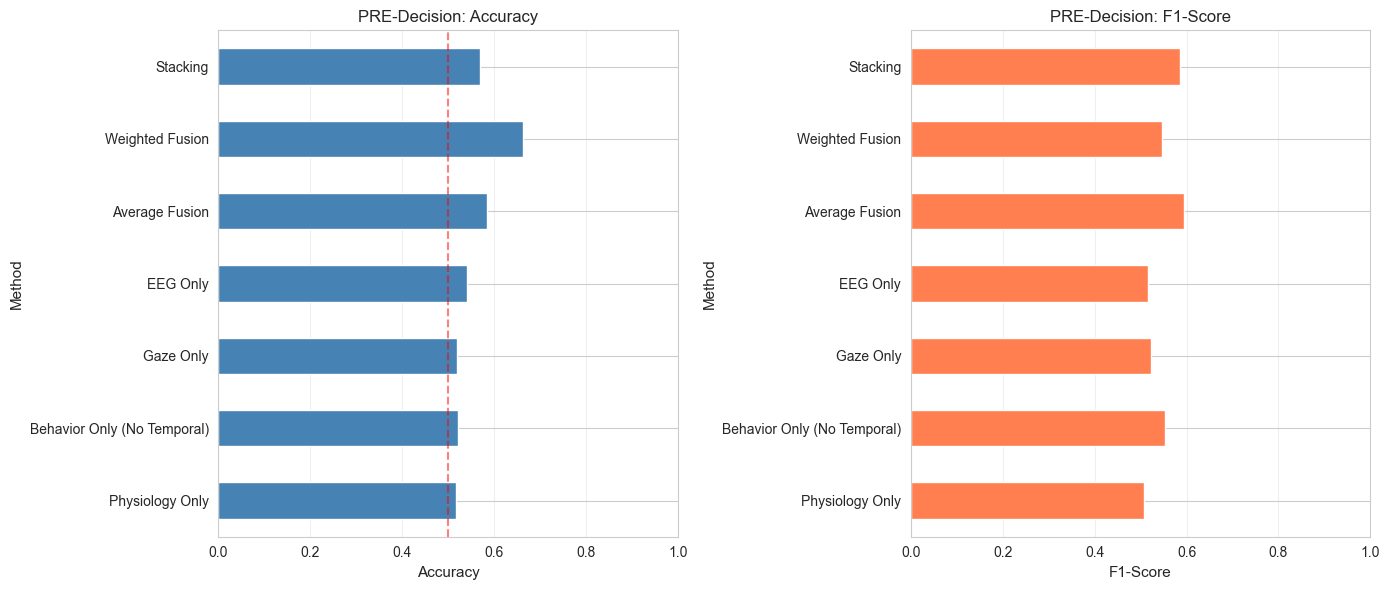

In [9]:
# Build comparison dataframe
comparison_data = {
    'Method': ['Physiology Only', 'Behavior Only (No Temporal)', 'Gaze Only', 'EEG Only'],
    'Accuracy': [acc_physio, acc_behavior, acc_gaze, acc_eeg],
    'F1-Score': [f1_physio, f1_behavior, f1_gaze, f1_eeg]
}

# Add fusion methods
comparison_data['Method'].extend(['Average Fusion', 'Weighted Fusion', 'Stacking'])
comparison_data['Accuracy'].extend([
    results_avg['accuracy_mean'],
    results_weighted['accuracy_mean'],
    results_stacking['accuracy_mean']
])
comparison_data['F1-Score'].extend([
    results_avg['f1_mean'],
    results_weighted['f1_mean'],
    results_stacking['f1_mean']
])

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*70)
print(f"PERFORMANCE COMPARISON ({TIMEFRAME}) - WITH EEG, NO TEMPORAL BEHAVIOR")
print("="*70)
print(comparison_df.to_string(index=False))

# Use shared plotting function
fig = plot_method_comparison(comparison_df, timeframe=TIMEFRAME)
plt.show()

## 8. Summary

In [10]:
print("\n" + "="*70)
print(f"SUMMARY ({TIMEFRAME}-DECISION) - WITH EEG, NO TEMPORAL BEHAVIOR")
print(f"Excluded: reaction_time, decision_time, ambiguity")
print(f"N subjects: {merged_df_eeg['subject_id'].nunique()}")
print("="*70)

print("\n1. INDIVIDUAL MODALITIES:")
print(f"   Physiology:  Acc={acc_physio:.3f}, F1={f1_physio:.3f}")
print(f"   Behavior:    Acc={acc_behavior:.3f}, F1={f1_behavior:.3f}")
print(f"   Gaze:        Acc={acc_gaze:.3f}, F1={f1_gaze:.3f}")
print(f"   EEG:         Acc={acc_eeg:.3f}, F1={f1_eeg:.3f}")

print("\n2. LATE FUSION METHODS:")
print(f"   Average:     Acc={results_avg['accuracy_mean']:.3f}, F1={results_avg['f1_mean']:.3f}")
print(f"   Weighted:    Acc={results_weighted['accuracy_mean']:.3f}, F1={results_weighted['f1_mean']:.3f}")
print(f"   Stacking:    Acc={results_stacking['accuracy_mean']:.3f}, F1={results_stacking['f1_mean']:.3f}")

print("\n3. MODALITY CONTRIBUTIONS (Weighted Fusion):")
for name, w in zip(modality_names, results_weighted['weights']):
    print(f"   {name:12s}: {w*100:5.1f}%")

best = comparison_df.loc[comparison_df['Accuracy'].idxmax()]
print(f"\n4. BEST METHOD: {best['Method']} (Acc={best['Accuracy']:.3f})")
print("\n" + "="*70)


SUMMARY (PRE-DECISION) - WITH EEG, NO TEMPORAL BEHAVIOR
Excluded: reaction_time, decision_time, ambiguity
N subjects: 82

1. INDIVIDUAL MODALITIES:
   Physiology:  Acc=0.518, F1=0.508
   Behavior:    Acc=0.522, F1=0.553
   Gaze:        Acc=0.519, F1=0.524
   EEG:         Acc=0.540, F1=0.517

2. LATE FUSION METHODS:
   Average:     Acc=0.585, F1=0.593
   Weighted:    Acc=0.663, F1=0.546
   Stacking:    Acc=0.569, F1=0.587

3. MODALITY CONTRIBUTIONS (Weighted Fusion):
   Physiology  :  33.2%
   Behavior    :  56.0%
   Gaze        :   3.4%
   EEG         :   7.3%

4. BEST METHOD: Weighted Fusion (Acc=0.663)



## 9. Modality Weights Visualization


MODALITY WEIGHTS (Influence on Prediction)
  Modality  Average  Weighted  Stacking
Physiology     0.25  0.332428  0.422379
  Behavior     0.25  0.559788  0.377929
      Gaze     0.25  0.034424  0.084997
       EEG     0.25  0.073360  0.114695


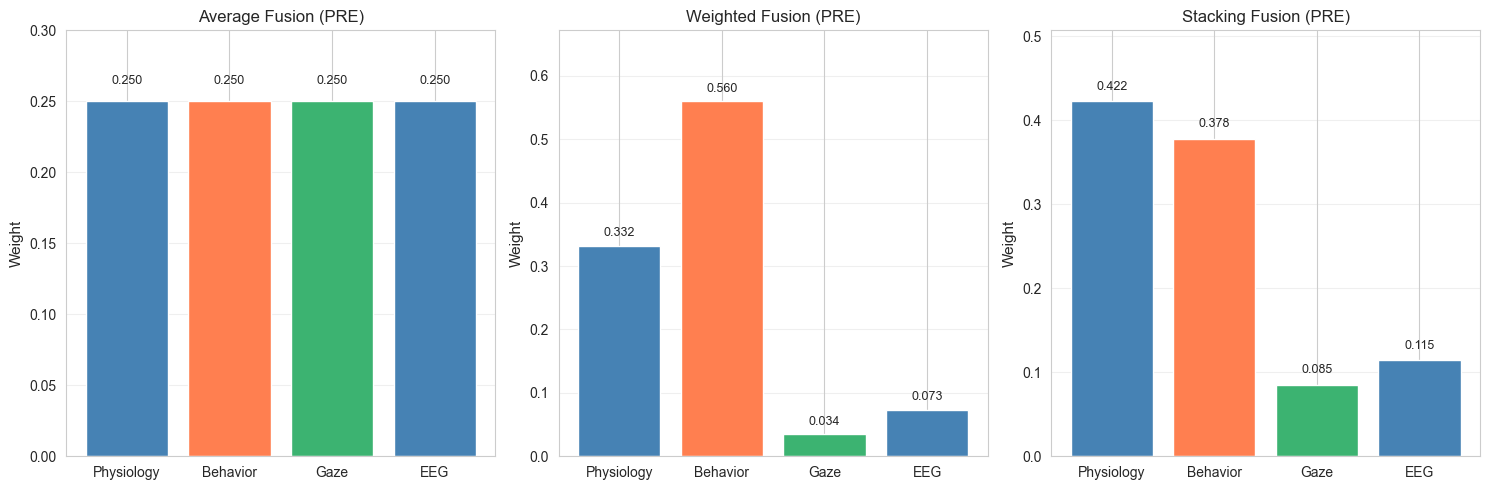

In [11]:
weights_df = pd.DataFrame({
    'Modality': modality_names,
    'Average': results_avg['weights'],
    'Weighted': results_weighted['weights'],
    'Stacking': results_stacking['weights']
})

print("\n" + "="*50)
print("MODALITY WEIGHTS (Influence on Prediction)")
print("="*50)
print(weights_df.to_string(index=False))

# Use shared plotting function
fig = plot_modality_weights(weights_df, timeframe=TIMEFRAME)
plt.show()

## 10. Save Results

In [12]:
# Save results using shared utility
import os
output_dir = f'../../data/results/fusion_model_results_no_temporal_eeg_{TIMEFRAME}'
os.makedirs(output_dir, exist_ok=True)

# 1. Save method comparison results
save_results(comparison_df, 
             f'{output_dir}/late_fusion_model_no_temporal_eeg_{TIMEFRAME}_method_comparison.csv')

# 2. Save modality weights
save_results(weights_df,
             f'{output_dir}/late_fusion_model_no_temporal_eeg_{TIMEFRAME}_modality_weights.csv')

# 3. Save weighted fusion summary
weighted_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Accuracy_SEM', 'F1_Score', 'F1_SEM', 'N_Subjects', 'N_Trials'],
    'Value': [
        results_weighted['accuracy_mean'],
        results_weighted['accuracy_sem'],
        results_weighted['f1_mean'],
        results_weighted['f1_sem'],
        results_weighted['n_subjects'],
        results_weighted['n_trials']
    ]
})
save_results(weighted_summary,
             f'{output_dir}/late_fusion_model_no_temporal_eeg_{TIMEFRAME}_weighted_fusion_summary.csv')

# 4. Save subject-level accuracies
subject_df = pd.DataFrame({
    'subject_id': list(results_weighted['subject_accs'].keys()),
    'accuracy': list(results_weighted['subject_accs'].values())
})
save_results(subject_df,
             f'{output_dir}/late_fusion_model_no_temporal_eeg_{TIMEFRAME}_subject_accuracies.csv')
print(f"  - {len(subject_df)} subjects, Mean accuracy: {subject_df['accuracy'].mean():.4f}")

# 5. Save excluded features info
excluded_info = pd.DataFrame({
    'excluded_feature': excluded_features,
    'reason': ['temporal/grouping variable'] * len(excluded_features)
})
save_results(excluded_info,
             f'{output_dir}/late_fusion_model_no_temporal_eeg_{TIMEFRAME}_excluded_features.csv')

print(f"\nAll results saved to: {output_dir}/")

✓ Saved results to: ../../data/results/fusion_model_results_no_temporal_eeg_PRE/late_fusion_model_no_temporal_eeg_PRE_method_comparison.csv
✓ Saved results to: ../../data/results/fusion_model_results_no_temporal_eeg_PRE/late_fusion_model_no_temporal_eeg_PRE_modality_weights.csv
✓ Saved results to: ../../data/results/fusion_model_results_no_temporal_eeg_PRE/late_fusion_model_no_temporal_eeg_PRE_weighted_fusion_summary.csv
✓ Saved results to: ../../data/results/fusion_model_results_no_temporal_eeg_PRE/late_fusion_model_no_temporal_eeg_PRE_subject_accuracies.csv
  - 82 subjects, Mean accuracy: 0.6627
✓ Saved results to: ../../data/results/fusion_model_results_no_temporal_eeg_PRE/late_fusion_model_no_temporal_eeg_PRE_excluded_features.csv

All results saved to: ../../data/results/fusion_model_results_no_temporal_eeg_PRE/
